In [1]:
from os.path import join as ospj
import pandas as pd
import numpy as np
import mne
from glob import glob
import os
from tqdm import tqdm
from fractions import Fraction
from scipy.signal import resample_poly
from scipy.signal import welch, lfilter
import pickle

from config import CONFIG
from utils import *

from matplotlib import pyplot as plt
import seaborn as sns

TARGET_SF = 256
# CLIP_SIZE = 45  # seconds
CLIP_SIZE = 10  # seconds
RAW_DATA_DIR = "/mnt/leif/littlab/data/Human_Data/CNT_iEEG_BIDS"

# make sz_table
sz_table = CONFIG.sz_times.copy()
sz_table.index = sz_table.index.map(CONFIG.hup_to_rid)
# move index to column and reindex
sz_table.reset_index(inplace=True)

master_bipolars = pd.read_csv(CONFIG.annotations_file, index_col=0)
master_bipolars['reg'] = master_bipolars.final_label.map(CONFIG.dkt_to_custom)

regs_li = pd.read_csv(ospj(CONFIG.data_dir, 'atlases', 'luts', 'dktg_reordered.csv'))
regs_li = regs_li.atlas_index.values
regs = pd.DataFrame(regs_li, columns=['reg'])


In [2]:
import matplotlib as mpl
mpl.style.use('figures.mplstyle')
MM_TO_IN = 0.0393701

In [3]:
all_sz_data = []
all_coords_data = []
all_regs_data = []
present_indices = []
missing_idx = []

print("Loading data...")
ind = sz_table.index[0]
row = sz_table.loc[ind]

fname = glob(
    ospj(
        RAW_DATA_DIR,
        row.Patient,
        "ses-clinical01/ieeg",
        f"{row.Patient}_ses-clinical01_task-ictal{int(row.start)}_*.edf")
)
fname = fname[0]
try:
    data = mne.io.read_raw_edf(fname, preload=True, verbose=False)
except:
    raise Exception(f"Could not load {fname}")
signals = data.get_data()  # (n_channels, n_samples)

fs = data.info["sfreq"]
ch_names = data.ch_names
ch_names = clean_labels(ch_names, pt=None)
ch_types = check_channel_types(ch_names)


Loading data...


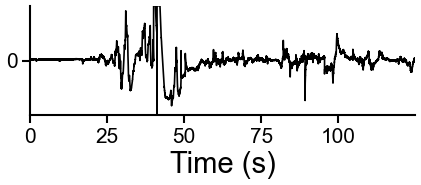

In [4]:
signal_idx = 0

t = np.arange(0, signals[signal_idx].shape[0]) / fs
fig, ax = plot_iEEG_data(signals[signal_idx][:, None], t, height=20*MM_TO_IN, width=40*MM_TO_IN)
plt.show()

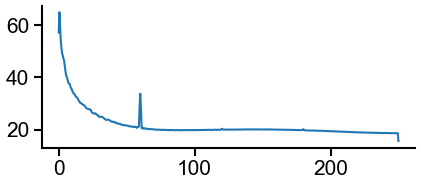

In [5]:
# plot psd
fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 20*MM_TO_IN))
f, Pxx = welch(signals[signal_idx]*1e6, fs, nperseg=fs*2)

ax.plot(f, 10*np.log10(Pxx))

[ 0.00000000e+00  0.00000000e+00 -1.05879118e-22 -1.05879118e-22
  0.00000000e+00  2.64697796e-23  5.29395592e-23  1.98523347e-23
  6.61744490e-24 -4.30133919e-23 -5.95570041e-23  8.27180613e-24
  6.61744490e-24  0.00000000e+00 -2.48154184e-24  2.06795153e-23
  3.30872245e-24  3.30872245e-24  8.27180613e-25 -1.24077092e-24
  3.72231276e-24  5.79026429e-24  1.65436123e-24  0.00000000e+00
  2.06795153e-24  5.37667398e-24  3.51551760e-24 -6.20385459e-25
 -8.27180613e-25 -1.86115638e-24 -8.27180613e-25  6.20385459e-25
 -1.44756607e-24  0.00000000e+00  2.27474668e-24  2.06795153e-25
  1.75775880e-24  9.30578189e-25 -7.23783036e-25 -5.16987883e-25
 -1.24077092e-24 -1.03397577e-24 -4.13590306e-25 -6.20385459e-25
  2.06795153e-25  0.00000000e+00  2.48154184e-24  9.30578189e-24
  1.65436123e-24  8.78879401e-25  3.10192730e-25 -1.96455395e-24
 -6.15215581e-24 -6.20385459e-24 -8.78879401e-25  1.34416850e-24
  2.58493941e-25 -2.79173457e-24 -1.75775880e-24 -7.75481824e-25
 -3.61891518e-25 -4.65289

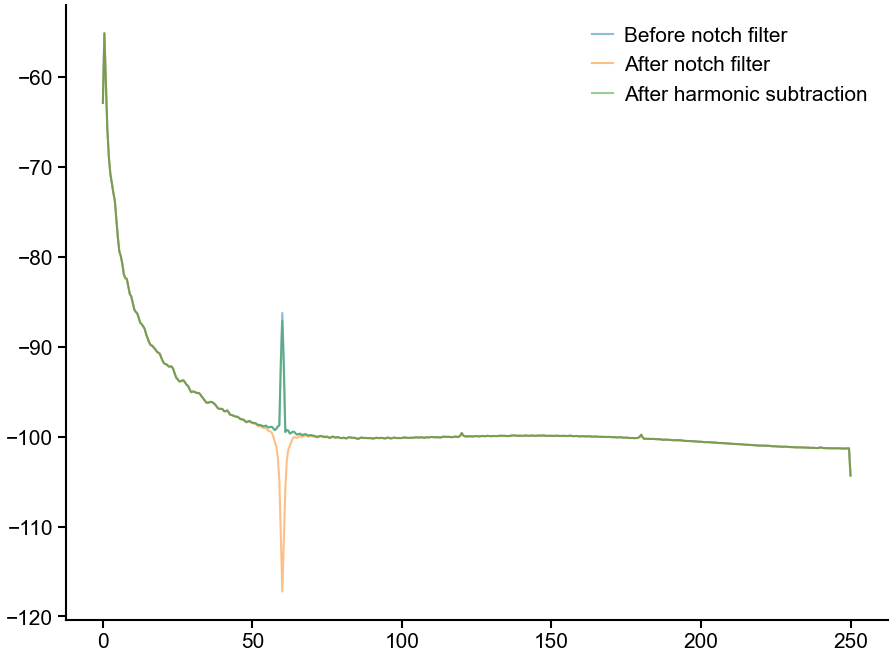

In [6]:
signal_idx = 0

# notch filter at 60 Hz
def powerline_filt1(sig, fs):
    return notch_filter(sig, fs)

def remove_harmonic(signals, freq, fs, order=30):
    t = np.arange(signals.shape[1]) / fs
    harmonic_signal = np.sin(2 * np.pi * freq * t)
    harmonic_signal = harmonic_signal[np.newaxis, :]  # Shape to (1, samples)

    # Estimate amplitude and phase
    estimated_amplitude = np.sum(signals * harmonic_signal, axis=1) / signals.shape[1]
    estimated_phase = np.arctan2(
        np.sum(signals * np.cos(2 * np.pi * freq * t), axis=1),
        np.sum(signals * np.sin(2 * np.pi * freq * t), axis=1)
    )
    
    # Broadcast estimated amplitude and phase for each channel
    estimated_harmonic = estimated_amplitude[:, np.newaxis] * np.sin(2 * np.pi * freq * t + estimated_phase[:, np.newaxis])

    # Smooth the estimated harmonic
    smoothed_estimate = lfilter([1 - 1/order], [1, -1/order], estimated_harmonic, axis=1)
    smoothed_estimate = estimated_harmonic
    
    # Subtract the smoothed estimate from the signals
    return signals - smoothed_estimate

def powerline_filt2(sig, fs):
    sig1 = remove_harmonic(sig, 180, fs)
    sig2 = remove_harmonic(sig1, 120, fs)
    sig3 = remove_harmonic(sig2, 60, fs)
    return sig3

signals_after_notch = powerline_filt1(signals.T, fs).T  # (n_channels, n_samples)
signals_after_harmsub = powerline_filt2(signals, fs)

fig, ax = plt.subplots(1, 1, figsize=(80*MM_TO_IN, 60*MM_TO_IN))
f, Pxx_orig = welch(signals[signal_idx], fs, nperseg=fs*2)
ax.plot(f, 10*np.log10(Pxx_orig), label='Before notch filter', alpha=0.5)

f, Pxx_notch = welch(signals_after_notch[signal_idx], fs, nperseg=fs*2)
ax.plot(f, 10*np.log10(Pxx_notch), label='After notch filter', alpha=0.5)

f, Pxx_harmsub = welch(signals_after_harmsub[signal_idx], fs, nperseg=fs*2)
ax.plot(f, 10*np.log10(Pxx_harmsub), label='After harmonic subtraction', alpha=0.5)

ax.legend()

# print the subtracted
print(Pxx_orig - Pxx_harmsub)

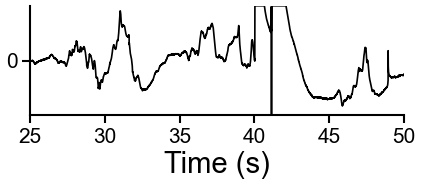

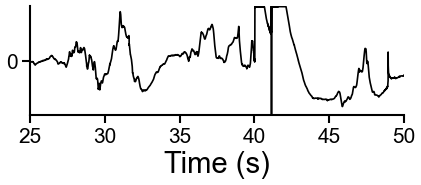

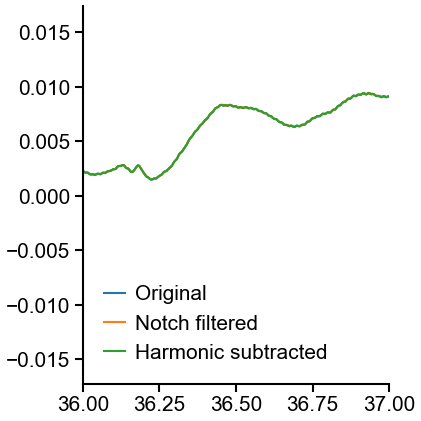

In [9]:
# plot the signals overlayed
t = np.arange(0, signals[signal_idx].shape[0]) / fs
fig, ax = plot_iEEG_data(signals[signal_idx][:, None], t, height=20*MM_TO_IN, width=40*MM_TO_IN)
ax.set_xlim([25, 50])
fig, ax = plot_iEEG_data(signals_after_notch[signal_idx][:, None], t, height=20*MM_TO_IN, width=40*MM_TO_IN)
ax.set_xlim([25, 50])

fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
t = np.arange(0, signals[signal_idx].shape[0]) / fs
ax.plot(t, signals[signal_idx], label='Original')
ax.plot(t, signals_after_notch[signal_idx], label='Notch filtered')
ax.plot(t, signals_after_harmsub[signal_idx], label='Harmonic subtracted')
ax.set_xlim([36, 37])
ax.legend(loc='best')

(0.0, 50.0)

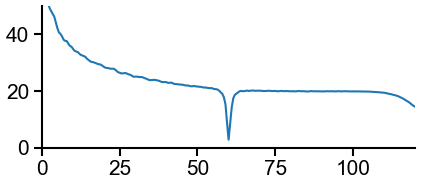

In [8]:

# low pass filter with 10th order butterworth filter
signals_after_bandpass = bandpass_filter(
    signals_after_notch, fs, order=10, lo=0.5, hi=120
)  # (n_channels, n_samples)


fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 20*MM_TO_IN))
f, Pxx = welch(signals_after_bandpass[signal_idx]*1e6, fs, nperseg=fs*2)

ax.plot(f, 10*np.log10(Pxx))
ax.set_xlim([0, 120]); ax.set_ylim([0, 50])

In [ ]:

# apply bipolar montage
signals, bipolar_ch_names = bipolar_montage(
    signals, ch_types
)  # (n_channels, n_samples)
signals = pd.DataFrame(
    signals, index=bipolar_ch_names.name
).T  # (n_samples, n_channels)

# downsample to 200 Hz
frac = Fraction(TARGET_SF, int(fs))
signals = resample_poly(
    signals, up=frac.numerator, down=frac.denominator
)  # (n_samples, n_channels)

# format signals into edf
signals = np.array(signals).T  # (n_channels, n_samples)
ch_types_for_edf = ["eeg"] * len(bipolar_ch_names)
new_info = mne.create_info(
    bipolar_ch_names.name.to_list(), TARGET_SF, ch_types_for_edf,
    verbose=False
)
new_data = mne.io.RawArray(signals, new_info, verbose=False)

# if there's an eeg annotation onset that starts at 30 seconds, then use 
# 15 seconds before to 30 seconds after as the seizure clip
# otherwise, use 45 seconds from the start of the clip
if data.annotations.onset[0] == 30:
    start = 30
else:
    start = 0


In [4]:
signals

array([[-1.31445433e-05, -2.46063121e-05, -2.48250044e-05, ...,
         1.11989434e-05,  1.04793049e-05,  8.22642016e-06],
       [-1.73838762e-05, -4.01492133e-05, -4.85519132e-05, ...,
        -5.14771321e-06, -6.96755695e-06, -7.32391310e-06],
       [ 1.42263139e-06,  4.66290380e-06,  2.73317417e-07, ...,
         2.22682141e-06, -5.11243030e-06,  2.90871433e-06],
       ...,
       [ 2.89986031e-05,  7.14849756e-06, -2.12390277e-05, ...,
        -2.05526695e-05, -2.29506543e-05, -2.71811673e-05],
       [-8.80608086e-06,  1.14369990e-05,  2.47133359e-05, ...,
        -1.83124896e-05, -1.39704151e-05, -1.34188964e-05],
       [-9.64756428e-06, -2.34873797e-05, -2.57161287e-05, ...,
         2.08914917e-05,  2.22760015e-05,  2.37226501e-05]])

## Making methods EEGs

In [94]:
sz_table[~pd.isna(sz_table.Semiology) & (sz_table.Semiology == 'FAS')]

,Patient,IEEGID,IEEGname,start,end,source,notes,Semiology
43,sub-RID0117,1.0,HUP107_phaseII,695316.0000,695342.150,json_x0003_,NaN,FAS
145,sub-RID0179,2.0,HUP111_phaseII_D02,137727.9800,137737.080,Erin Excel,looked for seizure-y annotations and portal ti...,FAS
146,sub-RID0179,2.0,HUP111_phaseII_D02,138590.8400,138600.920,Erin Excel,looked for seizure-y annotations and portal ti...,FAS
147,sub-RID0179,2.0,HUP111_phaseII_D02,161278.9600,161289.790,Erin Excel,looked for seizure-y annotations and portal ti...,FAS
148,sub-RID0179,2.0,HUP111_phaseII_D02,162630.0000,162639.230,Erin Excel,looked for seizure-y annotations and portal ti...,FAS
149,sub-RID0179,2.0,HUP111_phaseII_D02,167404.0000,167411.530,Erin Excel,looked for seizure-y annotations and portal ti...,FAS
155,sub-RID0042,1.0,HUP112_phaseII,31175.3300,31190.080,json_x0003_,NaN,FAS
156,sub-RID0042,1.0,HUP112_phaseII,40261.0400,40274.930,json_x0003_,NaN,FAS
385,sub-RID0307,1.0,HUP139_phaseII,147570.8600,147580.870,json_x0003_,NaN,FAS
450,sub-RID0322,1.0,HUP150_phaseII,14226.0000,14259.950,json_x0003_,NaN,FAS


In [98]:
idx1 = 31
idx2 = 32
idx3 = 155

display(sz_table.loc[[idx1, idx2, idx3]])

,Patient,IEEGID,IEEGname,start,end,source,notes,Semiology
31,sub-RID0101,1.0,HUP105_phaseII,1311001.00,1311052.56,json_x0003_,NaN,FBTCS
32,sub-RID0101,1.0,HUP105_phaseII,1694568.00,1694643.54,json_x0003_,NaN,FBTCS
155,sub-RID0042,1.0,HUP112_phaseII,31175.33,31190.08,json_x0003_,NaN,FAS


In [99]:
sigs = []
for idx in [idx1, idx2, idx3]:
    row = sz_table.loc[idx]
    fname = glob(
        ospj(
            RAW_DATA_DIR,
            row.Patient,
            "ses-clinical01/ieeg",
            f"{row.Patient}_ses-clinical01_task-ictal{int(row.start)}_*.edf")
    )
    fname = fname[0]
    try:
        data = mne.io.read_raw_edf(fname, preload=True, verbose=False)
    except:
        raise Exception(f"Could not load {fname}")
    signals = data.get_data()  # (n_channels, n_samples)

    fs = data.info["sfreq"]
    ch_names = data.ch_names
    ch_names = clean_labels(ch_names, pt=None)
    ch_types = check_channel_types(ch_names)

    signals = powerline_filt1(signals.T, fs).T  # (n_channels, n_samples)
    # bandpass filter
    signals = bandpass_filter(
        signals, fs, order=10, lo=0.5, hi=120
    )  # (n_channels, n_samples)

    signals = signals[:, int(30*fs):int(45*fs)]  # (n_channels, n_samples)
    # signals = signals[:, :int(15*fs)]  # (n_channels, n_samples)

    # notch filter at 60 Hz
    sigs.append(signals)  # (n_channels, n_samples)


# get every 10th channel
sigs = [s[::8] for s in sigs]
print([s.shape for s in sigs])


[(8, 7500), (8, 7500), (10, 7500)]


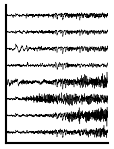

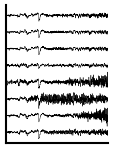

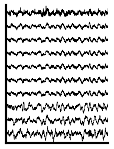

In [100]:
for i_sig, sig in enumerate(sigs):
    fig, ax = plot_iEEG_data(sig, np.arange(sig.shape[1])/fs, height=17*MM_TO_IN, width=14*MM_TO_IN)
    # ax.set_yticklabels([f"Ch {i}" for i in np.arange(sig.shape[0])])
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    # ax.set_xlim([0, 15])
    ax.set_xlabel("")
    # set linewidth to be very small
    for line in ax.lines:
        line.set_linewidth(0.1)

    # make x and y ticks invisible
    ax.tick_params(axis='both', which='both', length=0)

    # save
    fig.savefig(ospj(CONFIG.fig_dir, f"sz_{i_sig}_full.pdf"), bbox_inches='tight', pad_inches=0)


